# 5. Adding colours, legends and labels

Recreates the README's "5. Adding colors, legends and labels" figures:
bathymetry colour sets, `add_colour`/`add_colour_scale`, `add_legend`,
`add_labels`, and geopandas'/matplotlib's own plotting as the Python
equivalent of R's `sf`/`ggplot2` plotting methods (section 5.5).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap

import ccamlrgis as cg
import ccamlrgis.plot as cgplot
from ccamlrgis.plot import LegendItem
from ccamlrgis import datasets

depth_cmap = ListedColormap(cg.DEPTH_COLS)
depth_norm = BoundaryNorm(cg.DEPTH_CUTS, depth_cmap.N)
depth_cmap2 = ListedColormap(cg.DEPTH_COLS2)
depth_norm2 = BoundaryNorm(cg.DEPTH_CUTS2, depth_cmap2.N)
bathy_small = cg.small_bathy()
point_data = datasets.load_example("PointData")
poly_data = datasets.load_example("PolyData")
grid_data = datasets.load_example("GridData")

## 5.1. Bathymetry colours\n\nSimple set of colours:

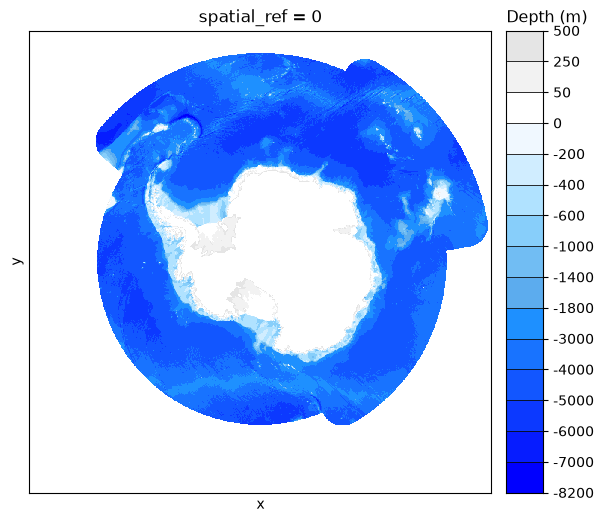

In [2]:
fig, ax = plt.subplots(figsize=(7, 6))
cgplot.basemap(ax=ax)
bathy_small.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
cgplot.add_colour_scale(ax=ax, cuts=cg.DEPTH_CUTS, cols=cg.DEPTH_COLS, size="8%")
plt.show()

Highlighting the Fishable Depth range (600-1800m):

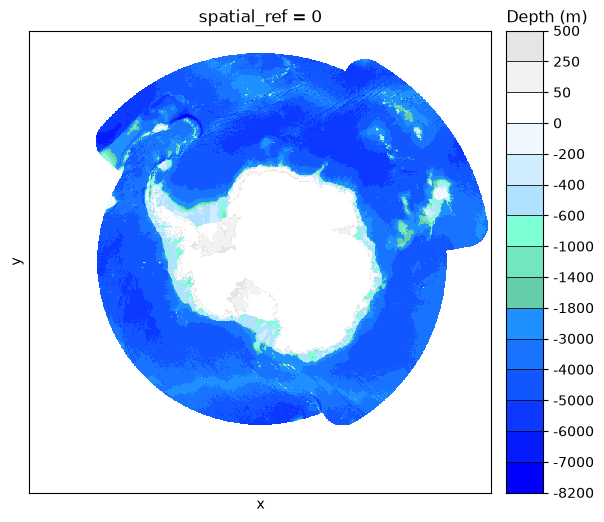

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
cgplot.basemap(ax=ax)
bathy_small.plot(ax=ax, cmap=depth_cmap2, norm=depth_norm2, add_colorbar=False)
cgplot.add_colour_scale(ax=ax, cuts=cg.DEPTH_CUTS2, cols=cg.DEPTH_COLS2, size="8%")
plt.show()

## 5.2. Adding colours to data

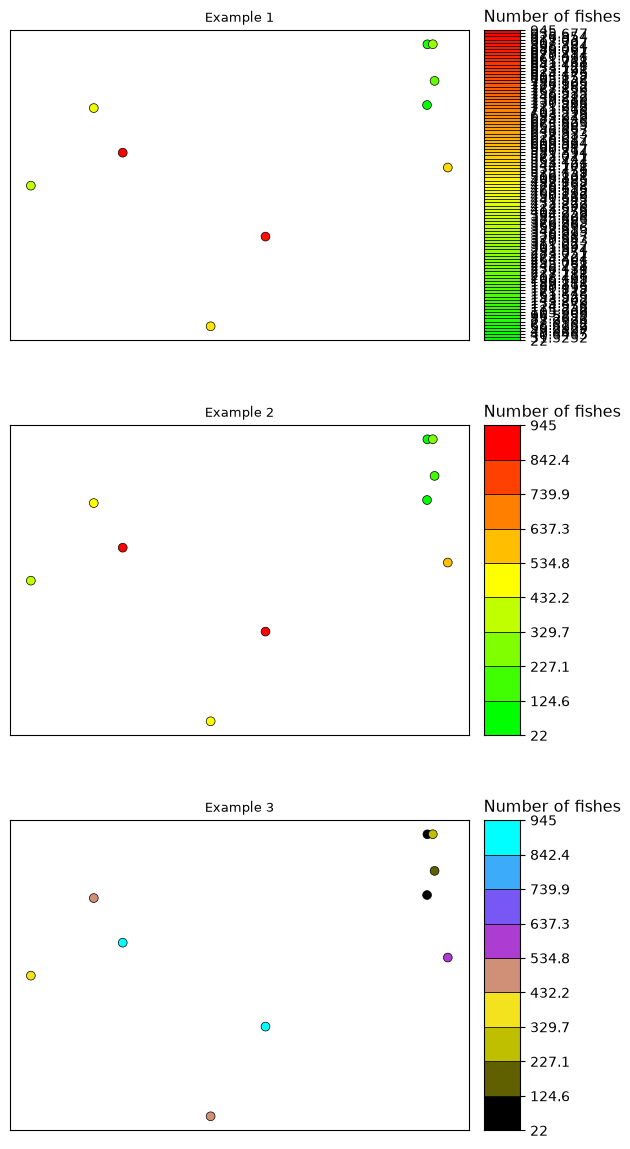

In [4]:
my_points = cg.create_points(point_data)

fig, axes = plt.subplots(3, 1, figsize=(6, 12))

# Example 1: default cuts and colours
my_cols = cg.add_colour(my_points["Nfishes"])
ax = cgplot.basemap(ax=axes[0])[1]
my_points.plot(ax=ax, color=list(my_cols["varcol"]), markersize=40, edgecolor="black", linewidth=0.5)
cgplot.add_colour_scale(ax=ax, cuts=my_cols["cuts"], cols=my_cols["cols"], title="Number of fishes", size="8%")
ax.set_title("Example 1", fontsize=9)

# Example 2: fewer cuts
my_cols = cg.add_colour(my_points["Nfishes"], cuts=10)
ax = cgplot.basemap(ax=axes[1])[1]
my_points.plot(ax=ax, color=list(my_cols["varcol"]), markersize=40, edgecolor="black", linewidth=0.5)
cgplot.add_colour_scale(ax=ax, cuts=np.round(my_cols["cuts"], 1), cols=my_cols["cols"], title="Number of fishes", size="8%")
ax.set_title("Example 2", fontsize=9)

# Example 3: same, with custom colours
my_cols = cg.add_colour(my_points["Nfishes"], cuts=10, cols=["black", "yellow", "purple", "cyan"])
ax = cgplot.basemap(ax=axes[2])[1]
my_points.plot(ax=ax, color=list(my_cols["varcol"]), markersize=40, edgecolor="black", linewidth=0.5)
cgplot.add_colour_scale(ax=ax, cuts=np.round(my_cols["cuts"], 1), cols=my_cols["cols"], title="Number of fishes", size="8%")
ax.set_title("Example 3", fontsize=9)

fig.tight_layout()
plt.show()

Adding colours to a grid with custom cuts (see also section 2.1's last example):

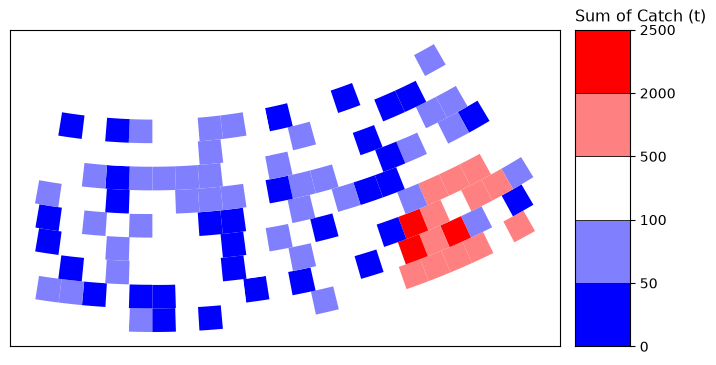

In [5]:
my_grid = cg.create_polygrids(grid_data, area=10000)
my_cuts = [0, 50, 100, 500, 2000, 2500]
grid_col = cg.add_colour(my_grid["Catch_sum"], cuts=my_cuts, cols=["blue", "white", "red"])

fig, ax = plt.subplots(figsize=(8, 6))
cgplot.basemap(ax=ax)
my_grid.plot(ax=ax, color=list(grid_col["varcol"]), linewidth=0.1)
cgplot.add_colour_scale(ax=ax, cuts=grid_col["cuts"], cols=grid_col["cols"], title="Sum of Catch (t)", size="10%")
plt.show()

## 5.3. Adding legends\n\nA colour scale plus a plain matplotlib legend for point symbols:

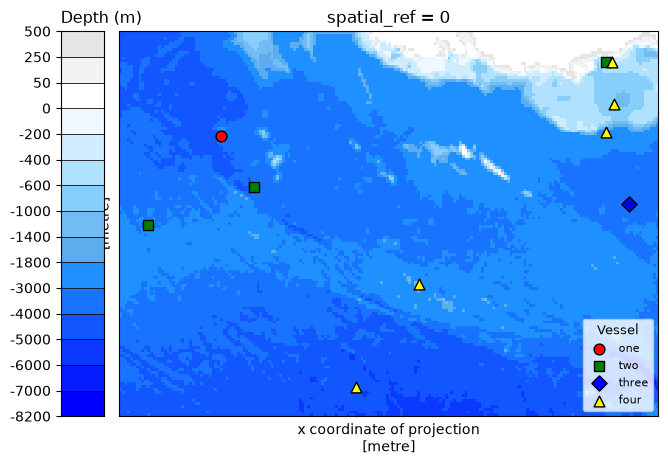

In [6]:
my_points = cg.create_points(point_data)
bathy_cr = bathy_small.rio.clip_box(*(my_points.total_bounds + [-100000, -100000, 100000, 100000]))

fig, ax = plt.subplots(figsize=(8, 5))
cgplot.basemap(ax=ax)
bathy_cr.plot(ax=ax, cmap=depth_cmap, norm=depth_norm, add_colorbar=False)
cgplot.add_colour_scale(ax=ax, cuts=cg.DEPTH_CUTS, cols=cg.DEPTH_COLS, size="8%", loc="left")

markers = {"one": ("o", "red"), "two": ("s", "green"), "three": ("D", "blue"), "four": ("^", "yellow")}
for name, (marker, colour) in markers.items():
    sub = my_points[my_points["name"] == name]
    ax.scatter(sub["x"], sub["y"], marker=marker, color=colour, edgecolor="black", s=60, label=name)
ax.legend(title="Vessel", loc="lower right", fontsize=8, title_fontsize=9)
plt.show()

For a more complete and customisable legend, `add_legend` (this port's
from-scratch, matplotlib-native reimplementation of R's ~680-line
`add_Legend` -- see `docs/porting_notes.md`) supports six shape types with
fill/border/hatch styling:

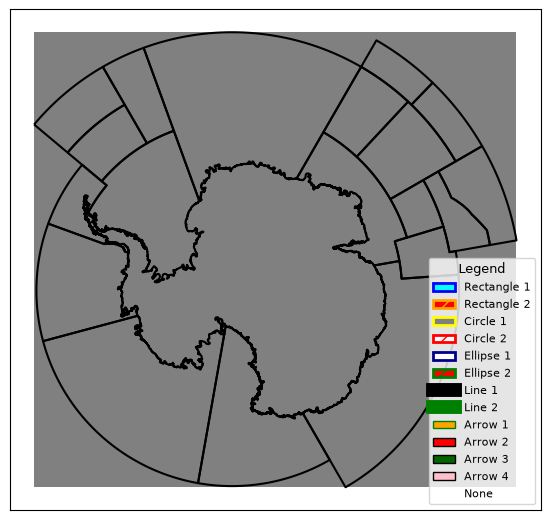

In [7]:
asds = cg.load_asds()
bx = __import__("shapely.geometry", fromlist=["box"]).box(*asds.total_bounds)

items = [
    LegendItem("Rectangle 1", shape="rectangle", fill="cyan", border="blue", linewidth=2),
    LegendItem("Rectangle 2", shape="rectangle", fill="red", border="orange", linewidth=2, hatch="//"),
    LegendItem("Circle 1", shape="circle", fill="grey", border="yellow", linewidth=2),
    LegendItem("Circle 2", shape="circle", fill="white", border="red", linewidth=2, hatch="//"),
    LegendItem("Ellipse 1", shape="ellipse", fill="white", border="darkblue", linewidth=2),
    LegendItem("Ellipse 2", shape="ellipse", fill="red", border="green", linewidth=2, hatch="//"),
    LegendItem("Line 1", shape="line", fill="black", linewidth=5),
    LegendItem("Line 2", shape="line", fill="green", linewidth=5),
    LegendItem("Arrow 1", shape="arrow", fill="orange", border="green"),
    LegendItem("Arrow 2", shape="arrow", fill="red", border="black"),
    LegendItem("Arrow 3", shape="arrow", fill="darkgreen", border="black"),
    LegendItem("Arrow 4", shape="arrow", fill="pink", border="black", hatch="//"),
    LegendItem("None", shape="none"),
]

fig, ax = plt.subplots(figsize=(8, 6.5))
cgplot.basemap(ax=ax)
import geopandas as gpd
gpd.GeoSeries([bx], crs=cg.CCAMLR_CRS).plot(ax=ax, color="grey")
asds.boundary.plot(ax=ax, color="black")
cgplot.add_legend(ax=ax, items=items, title="Legend", loc="lower right", fontsize=8)
plt.show()

## 5.4. Adding labels\n\nExample 1: 'auto' mode -- ASDs in bold red, MPAs/EEZs in large, green, vertical text:

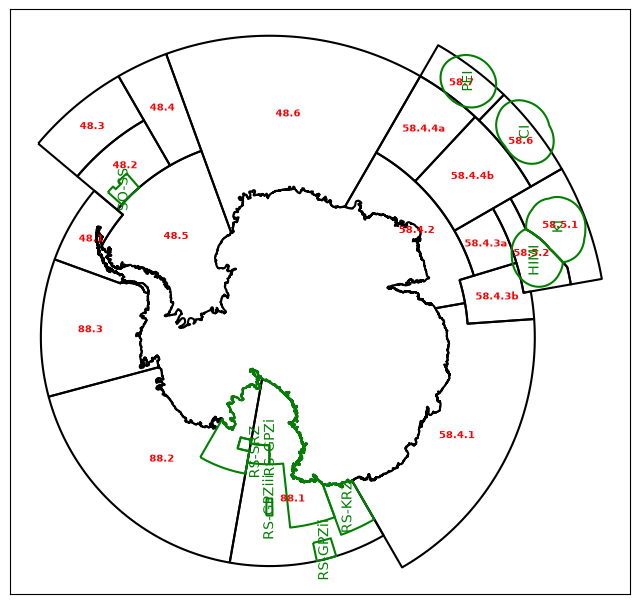

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
cgplot.basemap(ax=ax)
asds.boundary.plot(ax=ax, color="black")
cgplot.add_labels(ax=ax, mode="auto", layer="ASDs", fontsize=7.5, fonttype=2, colour="red")
mpas = cg.load_mpas()
eezs = cg.load_eezs()
mpas.boundary.plot(ax=ax, color="green")
eezs.boundary.plot(ax=ax, color="green")
cgplot.add_labels(ax=ax, mode="auto", layer=["EEZs", "MPAs"], fontsize=10, colour="green", angle=90)
plt.show()

`add_labels(mode='manual')` (click-to-place labelling) has no headless
Python equivalent and is dropped -- see `docs/porting_notes.md` deviation
2. Use `mode='table'` (this port's replacement for R's `mode='input'`)
to place labels from a table built programmatically instead.

## 5.5. Using geopandas (Python's `sf` equivalent)

Every `ccamlrgis` function that returns spatial data returns a plain
`geopandas.GeoDataFrame` -- normal pandas indexing/columns plus a
`geometry` column, and geopandas' own `.plot()` (matplotlib-based) fills
the role of R's `sf`/`ggplot2` plotting methods described in this
section.

In [9]:
my_polys = cg.create_polys(poly_data)
my_polys

,ID,Catch_min,Nfishes_min,n_min,Catch_max,Nfishes_max,n_max,Catch_mean,Nfishes_mean,n_mean,...,Catch_sd,Nfishes_sd,n_sd,Catch_median,Nfishes_median,n_median,geometry,AreaKm2,Labx,Laby
0,one,52.612620,11.0,1,71.659087,329.0,4,64.173799,172.500000,2.5,...,9.084736,153.391656,1.290994,66.211745,175.0,2.5,"POLYGON ((-290035.871 -1644875.163, -287164.58...",187281.3,-1.705198e+05,-1.949051e+06
1,two,23.120323,116.0,5,73.493826,954.0,8,51.949512,505.000000,6.5,...,22.264999,428.918796,1.290994,55.591949,475.0,6.5,"POLYGON ((-423880.67 -2403946.735, -419684.347...",95294.2,7.782919e-11,-2.483470e+06
2,three,10.233933,13.0,9,95.577745,988.0,14,52.503128,412.333333,11.5,...,32.152675,382.868472,1.870829,54.153674,341.5,11.5,"POLYGON ((480755.064 -2726497.454, 485512.965 ...",361556.2,7.869331e+05,-2.846388e+06


`plot(MyPolys)` in R facets every numeric column automatically (up to 9); geopandas has no direct one-liner for that, so here it's done explicitly for a representative subset of columns:

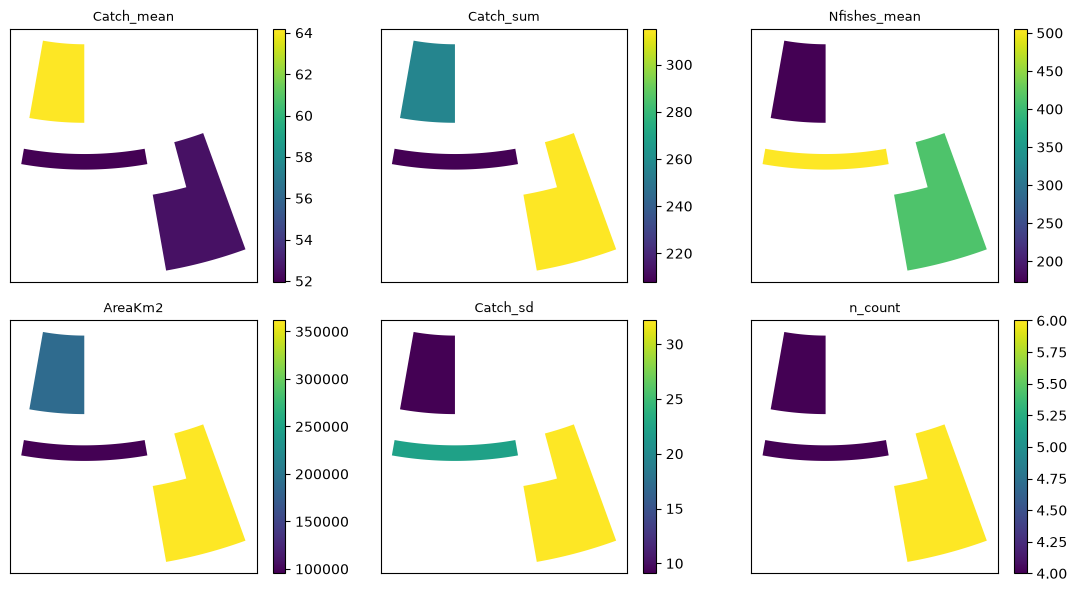

In [10]:
facet_cols = ["Catch_mean", "Catch_sum", "Nfishes_mean", "AreaKm2", "Catch_sd", "n_count"]
facet_cols = [c for c in facet_cols if c in my_polys.columns][:6]

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for ax, col in zip(axes.flat, facet_cols):
    my_polys.plot(column=col, ax=ax, legend=True, cmap="viridis")
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()

`plot(MyPolys["Catch_mean"])`: a single named column, with a graticule (`add_reference_grid`, this port's equivalent of `st_graticule`) instead of R's key/axes styling:

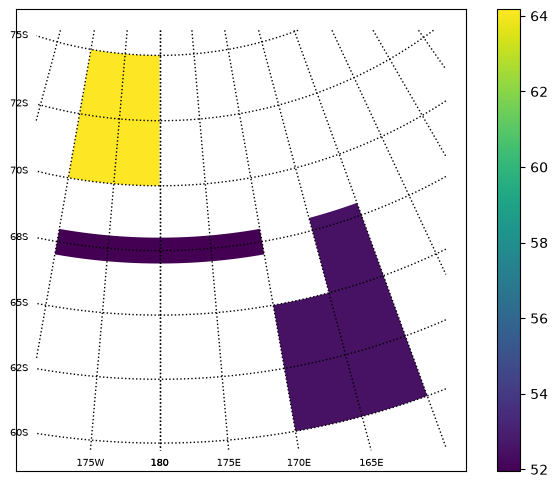

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
my_polys.plot(column="Catch_mean", ax=ax, legend=True, cmap="viridis")
cgplot.add_reference_grid(ax=ax, res_lat=2.5, res_lon=5, fontsize=7)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

R's `ggplot2`/`gridExtra` multi-panel example has a direct geopandas +
matplotlib-subplots equivalent (no extra plotting library needed):

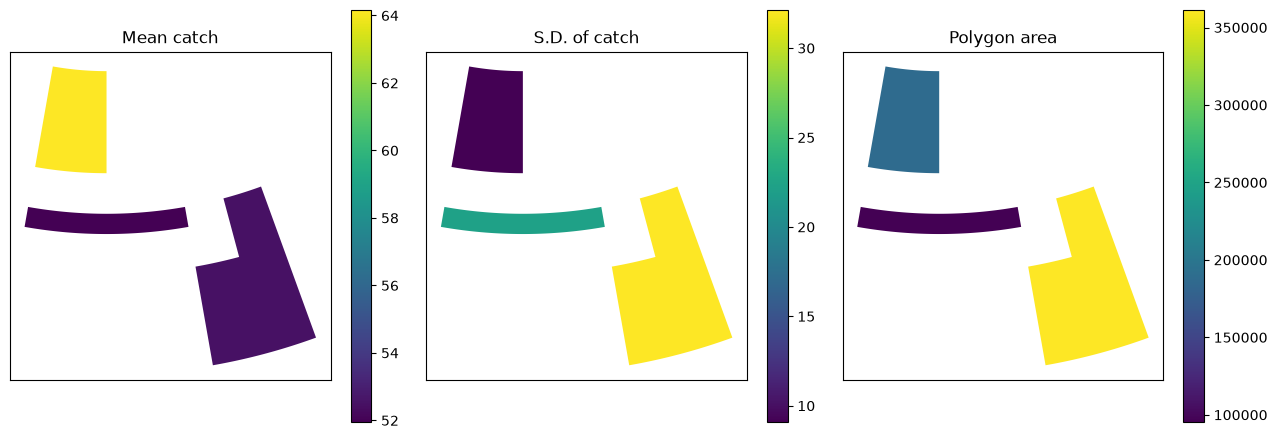

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
my_polys.plot(column="Catch_mean", ax=axes[0], legend=True, cmap="viridis")
axes[0].set_title("Mean catch")
my_polys.plot(column="Catch_sd", ax=axes[1], legend=True, cmap="viridis")
axes[1].set_title("S.D. of catch")
my_polys.plot(column="AreaKm2", ax=axes[2], legend=True, cmap="viridis")
axes[2].set_title("Polygon area")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()